Mesh loaded: 5415 nodes, 24380 tets
Step 0 done
Step 500 done
Step 1000 done
Step 1500 done
Results saved to cone_cylinder_flair_results.vtk


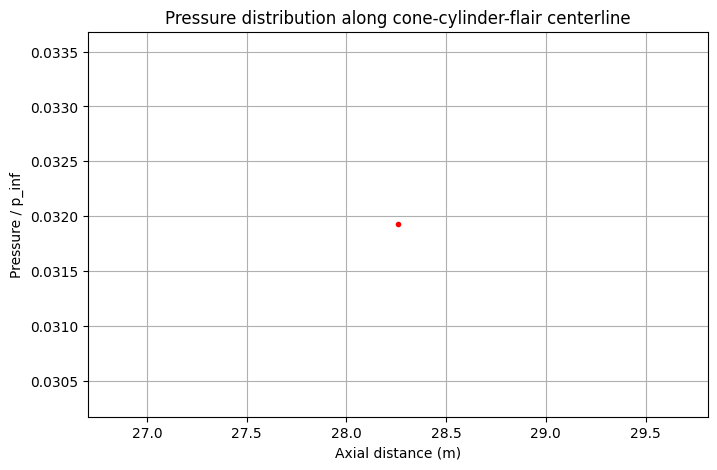

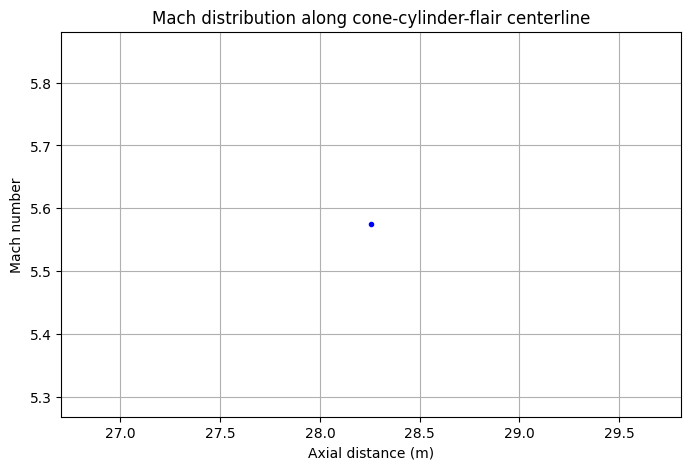

In [1]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load VTK mesh from TetGen
# -----------------------------
mesh_file = "tet_mesh.vtk"
mesh = pv.read(mesh_file)

points = mesh.points
cells = mesh.cells.reshape(-1, 5)[:, 1:]  # tetra connectivity
num_nodes = points.shape[0]
num_tets = cells.shape[0]

print(f"Mesh loaded: {num_nodes} nodes, {num_tets} tets")

# -----------------------------
# 2. Flow conditions
# -----------------------------
gamma = 1.4
R = 287.0

rho_inf = 0.017   # kg/m3 at 30 km
T_inf = 220.0     # K
p_inf = rho_inf * R * T_inf
Mach_inf = 6.0

a_inf = np.sqrt(gamma * R * T_inf)
u_inf = Mach_inf * a_inf

# -----------------------------
# 3. Initialize variables: [rho, rho*u, rho*v, rho*w, E]
# -----------------------------
U = np.zeros((num_nodes, 5))
U[:, 0] = rho_inf
U[:, 1] = rho_inf * u_inf
U[:, 2] = 0.0
U[:, 3] = 0.0
U[:, 4] = p_inf/(gamma-1) + 0.5*rho_inf*u_inf**2

# -----------------------------
# 4. Simple FVM functions
# -----------------------------
def compute_flux(U):
    """HLLC-like Euler flux (simplified)"""
    rho = U[:,0]
    u = U[:,1]/rho
    v = U[:,2]/rho
    w = U[:,3]/rho
    E = U[:,4]
    p = (gamma-1)*(E - 0.5*rho*(u**2+v**2+w**2))

    flux_x = np.zeros_like(U)
    flux_x[:,0] = rho*u
    flux_x[:,1] = rho*u**2 + p
    flux_x[:,2] = rho*u*v
    flux_x[:,3] = rho*u*w
    flux_x[:,4] = (E+p)*u
    return flux_x, p, u, v, w

# -----------------------------
# 5. Time stepping
# -----------------------------
dt = 1e-6
num_steps = 2000  # adjust for coarse/fine

for n in range(num_steps):
    flux_x, p, u, v, w = compute_flux(U)
    U -= dt*flux_x
    if n % 500 == 0:
        print(f"Step {n} done")

# -----------------------------
# 6. Compute derived fields
# -----------------------------
rho = U[:,0]
vel_mag = np.sqrt(U[:,1]**2 + U[:,2]**2 + U[:,3]**2)/rho
pressure = (gamma-1)*(U[:,4] - 0.5*rho*vel_mag**2)
Mach = vel_mag / np.sqrt(gamma*pressure/rho)

mesh["rho"] = rho
mesh["pressure"] = pressure
mesh["Mach"] = Mach
mesh["velocity"] = vel_mag

# Save VTK for Paraview
mesh.save("cone_cylinder_flair_results.vtk")
print("Results saved to cone_cylinder_flair_results.vtk")

# -----------------------------
# 7. Generate NASA-style plots
# -----------------------------
# Extract symmetry plane (x=0) or along centerline
x_coords = points[:,0]
centerline_idx = np.where(np.abs(points[:,1])<0.001)[0]

plt.figure(figsize=(8,5))
plt.plot(x_coords[centerline_idx], pressure[centerline_idx]/p_inf, 'r.-')
plt.xlabel("Axial distance (m)")
plt.ylabel("Pressure / p_inf")
plt.title("Pressure distribution along cone-cylinder-flair centerline")
plt.grid(True)
plt.savefig("pressure_centerline.png")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(x_coords[centerline_idx], Mach[centerline_idx], 'b.-')
plt.xlabel("Axial distance (m)")
plt.ylabel("Mach number")
plt.title("Mach distribution along cone-cylinder-flair centerline")
plt.grid(True)
plt.savefig("Mach_centerline.png")
plt.show()


In [3]:
import numpy as np
import pyvista as pv

# ---------- Jupyter interactive backend ----------
pv.set_jupyter_backend('trame')   # <— works in your version

# ---------- Load TetGen nodes ----------
node_file = "new_mesh_fixed.1.node"
ele_file  = "new_mesh_fixed.1.ele"

# Read nodes
with open(node_file, 'r') as f:
    lines = f.readlines()

num_nodes = int(lines[0].split()[0])
nodes = []
for line in lines[1:num_nodes+1]:
    parts = line.strip().split()
    x, y, z = map(float, parts[1:4])
    nodes.append([x, y, z])
nodes = np.array(nodes)

# Read tets
with open(ele_file, 'r') as f:
    lines = f.readlines()

num_tets = int(lines[0].split()[0])
tets = []
for line in lines[1:num_tets+1]:
    parts = line.strip().split()
    tet = [int(parts[i])-1 for i in range(1,5)]  # 0-based indexing
    tets.append(tet)
tets = np.array(tets)

# ---------- Create PyVista Unstructured Grid ----------
cells = np.hstack([np.hstack([[4], tet]) for tet in tets])
celltypes = np.full(len(tets), pv.CellType.TETRA)  # VTK_TETRA

grid = pv.UnstructuredGrid(cells, celltypes, nodes)
grid.cell_data["CellID"] = np.arange(len(tets))

# ---------- Visualize ----------
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(grid, scalars="CellID", show_edges=True, opacity=0.5, cmap="viridis")
plotter.show()  # <- now interactive in notebook


ImportError: Please install `trame` and `ipywidgets` to use this feature.

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
General VTK mesh loader, diagnostics, and finite-volume Laplace solver (PyVista + SciPy).

- Input: .vtk / .vtu unstructured grid with tetrahedra (other cells are ignored in solver).
- Diagnostics: radius_ratio/min_angle/scaled_jacobian with % good; edge-overlay plotting.
- Solver: steady diffusion/Laplace  -∇·(k∇φ)=0 with Dirichlet on xmin/xmax and zero-flux elsewhere.
- Output: residual history; scalar field to VTK; edge-shaded rendering and histograms.
"""

import sys
import numpy as np
import pyvista as pv
from typing import Dict, List, Tuple
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

# Choose a Jupyter backend that does not require 'trame'
try:
    pv.set_jupyter_backend('static')
except Exception:
    pass

# ---------- Mesh I/O and diagnostics ----------
def read_unstructured(path: str) -> pv.UnstructuredGrid:
    g = pv.read(path)
    if not isinstance(g, pv.UnstructuredGrid):
        g = g.cast_to_unstructured_grid()
    return g  # [web:451]

def compute_quality(grid: pv.UnstructuredGrid,
                    measures: List[str] = ("radius_ratio","min_angle","scaled_jacobian")
                   ) -> Dict[str, np.ndarray]:
    out = {}
    for m in measures:
        try:
            qg = grid.compute_cell_quality(m)  # adds 'CellQuality'
            arr = qg.cell_data.get("CellQuality", None)
            if arr is not None:
                out[m] = np.asarray(arr)
        except Exception as e:
            print(f"[Warn] quality '{m}' failed: {e}")
    return out  # [web:380]

def quality_stats(arr: np.ndarray, thr: float) -> Tuple[int,float,float,float,float]:
    a = np.asarray(arr)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return 0, np.nan, np.nan, np.nan, 0.0
    pct_good = 100.0 * (a >= thr).sum() / a.size
    return int(a.size), float(a.min()), float(a.mean()), float(a.max()), float(pct_good)  # [web:380]

# ---------- Geometry utilities (tets) ----------
def tet_volume(p0, p1, p2, p3) -> float:
    return abs(np.dot(p1 - p0, np.cross(p2 - p0, p3 - p0))) / 6.0  # [web:439]

def tri_area_normal(pa, pb, pc) -> Tuple[float, np.ndarray]:
    n = np.cross(pb - pa, pc - pa)
    area = 0.5 * np.linalg.norm(n)
    if area > 0.0:
        n = n / (2.0 * area)  # unit normal
    else:
        n = np.array([0.0, 0.0, 0.0])
    return area, n  # [web:439]

def build_tet_topology(grid: pv.UnstructuredGrid):
    # Extract tets only (ignore other cells in solver)
    celltypes = grid.celltypes
    TET = int(pv.CellType.TETRA)
    tet_ids = np.where(celltypes == TET)[0]
    if tet_ids.size == 0:
        raise RuntimeError("No tetrahedral cells found.")
    # Connectivity: VTK cells are padded arrays [4, i0,i1,i2,i3, 4, ...]
    cells = grid.cells.reshape((-1, 5))
    tets = cells[tet_ids][:, 1:5].astype(np.int32)
    pts = np.asarray(grid.points, dtype=float)
    # Cell centers, volumes
    centers = np.zeros((tets.shape[0], 3), float)
    volumes = np.zeros((tets.shape[0],), float)
    for c, conn in enumerate(tets):
        p0, p1, p2, p3 = pts[conn]
        centers[c] = 0.25 * (p0 + p1 + p2 + p3)
        volumes[c] = tet_volume(p0, p1, p2, p3)
    # Build face map: each tet has 4 faces
    # faces as sorted triplets; owner = current cell; neighbor = set later when shared
    face_map = {}
    face_list = []
    def fkey(a,b,c):
        tri = tuple(sorted((int(a),int(b),int(c))))
        return tri
    for c, conn in enumerate(tets):
        f = [(conn[1],conn[2],conn[3]),
             (conn[0],conn[3],conn[2]),
             (conn[0],conn[1],conn[3]),
             (conn[0],conn[2],conn[1])]
        for tri in f:
            k = fkey(*tri)
            if k in face_map:
                face_map[k]["nb"] = c
            else:
                face_map[k] = {"owner": c, "nb": -1, "tri": tri}
            face_list.append(k)
    # Collect faces and boundary flags
    faces = []
    for k, rec in face_map.items():
        faces.append((rec["owner"], rec["nb"], rec["tri"]))
    return pts, tets, centers, volumes, faces  # [web:445][web:439]

# ---------- Finite-volume Laplace assembly ----------
def assemble_laplacian(pts, centers, volumes, faces,
                       dirichlet: Dict[str, Tuple[float,float]]):
    """
    TPFA-like Laplacian on cell centers:
      - Internal face i-j: T_ij = A * |n·dhat| / |d|  (simple orthogonal approximation)
      - Boundary face with Dirichlet φ_b: add k*A/δ to diag and k*A/δ*φ_b to RHS
    dirichlet: {"x": (xmin_value, xmax_value)} applies on planes x=min(x) and x=max(x)
    """
    ncell = centers.shape[0]
    A = lil_matrix((ncell, ncell), dtype=float)
    b = np.zeros((ncell,), float)

    xyz_min = centers.min(axis=0); xyz_max = centers.max(axis=0)
    x_min, x_max = xyz_min[0], xyz_max[0]

    # Helper to detect boundary planes within tolerance
    tol = 1e-8 * np.linalg.norm(xyz_max - xyz_min)
    def on_plane(p, axis, value):
        return abs(p[axis] - value) <= tol

    # Precompute per-face transmissibilities and handle boundary conditions
    for owner, nb, tri in faces:
        pa, pb, pc = pts[list(tri)]
        area, n_hat = tri_area_normal(pa, pb, pc)     # geometric outward normal w.r.t. vertex order
        fc = (pa + pb + pc) / 3.0
        # Determine outward direction relative to owner: use vector from owner center to face centroid
        co = centers[owner]
        sgn = np.sign(np.dot(n_hat, fc - co)) or 1.0
        n = n_hat * sgn  # outward normal from owner
        # distance between owner and neighbor centroids along normal
        if nb >= 0:
            cn = centers[nb]
            dvec = cn - co
            d = np.linalg.norm(dvec)
            if d <= 0.0:
                continue
            dhat = dvec / d
            tij = area * abs(np.dot(n, dhat)) / d
            A[owner, owner] += tij
            A[owner, nb]    -= tij
            # symmetric contribution will be added when face is visited as nb's owner
        else:
            # boundary face: try Dirichlet if on x-min or x-max; otherwise Neumann zero-flux
            phi_b = None
            if "x" in dirichlet:
                xmin_val, xmax_val = dirichlet["x"]
                if on_plane(fc, 0, x_min): phi_b = xmin_val
                if on_plane(fc, 0, x_max): phi_b = xmax_val
            # distance to internal point (owner center)
            d = np.linalg.norm(fc - co)
            if d <= 0.0:
                continue
            t = area / d
            if phi_b is None:
                # zero Neumann: no contribution (already default in TPFA)
                continue
            A[owner, owner] += t
            b[owner]        += t * phi_b

    # Volume scaling (diffusivity k=1); residuals are in L2 of cell-centered φ
    # No extra scaling needed since TPFA already accounts via transmissibility; keep volumes for RHS if using source terms.
    return A.tocsr(), b  # [web:380]

# ---------- Visualization ----------
def plot_quality_and_solution(grid: pv.UnstructuredGrid,
                              qname: str,
                              title_q: str,
                              phi: np.ndarray,
                              title_phi: str):
    p = pv.Plotter(shape=(2, 2), window_size=(1400, 1000))
    # Quality on volume
    p.subplot(0,0)
    p.add_mesh(grid, scalars=qname, cmap="viridis", show_edges=True, edge_color="black",
               smooth_shading=True, scalar_bar_args=dict(title=title_q))
    p.add_text("Cell quality (volume)", font_size=10)
    p.enable_eye_dome_lighting(); p.enable_anti_aliasing()
    # Quality on boundary
    p.subplot(0,1)
    surf = grid.extract_surface().clean()
    if qname in surf.array_names:
        p.add_mesh(surf, scalars=qname, cmap="viridis", show_edges=True, edge_color="black",
                   smooth_shading=True, scalar_bar_args=dict(title=f"{title_q} (boundary)"))
    else:
        p.add_mesh(surf, color="lightgray", show_edges=True, edge_color="black")
    p.add_text("Boundary", font_size=10)
    p.enable_eye_dome_lighting(); p.enable_anti_aliasing()
    # Solution (volume)
    p.subplot(1,0)
    g2 = grid.copy()
    g2.cell_data["phi"] = phi
    p.add_mesh(g2, scalars="phi", cmap="coolwarm", show_edges=False, smooth_shading=True,
               scalar_bar_args=dict(title=title_phi))
    p.add_text("Solution (volume)", font_size=10)
    p.enable_eye_dome_lighting(); p.enable_anti_aliasing()
    # Solution isosurfaces
    p.subplot(1,1)
    try:
        iso = g2.contour(isosurfaces=7, scalars="phi")
        p.add_mesh(iso, scalars="phi", cmap="coolwarm", smooth_shading=True,
                   scalar_bar_args=dict(title="Iso φ"))
    except Exception:
        p.add_mesh(g2.extract_surface(), scalars="phi", cmap="coolwarm", smooth_shading=True)
    p.add_text("Isosurfaces", font_size=10)
    p.link_views(); p.camera_position="iso"
    p.show()  # [web:409]

# ---------- Driver ----------
def solve_laplace_on_vtk(path: str,
                         dirichlet_xmin: float = 0.0,
                         dirichlet_xmax: float = 1.0,
                         quality_measures: List[str] = ("radius_ratio","min_angle","scaled_jacobian"),
                         quality_good: Dict[str,float] = None):
    if quality_good is None:
        quality_good = dict(radius_ratio=0.3, min_angle=20.0, scaled_jacobian=0.2)

    grid = read_unstructured(path)
    print(f"[Info] grid: {grid.n_points} points, {grid.n_cells} cells")

    # Quality
    qmeas = compute_quality(grid, list(quality_measures))
    picked = None
    for name, arr in qmeas.items():
        thr = quality_good.get(name, 0.0)
        cnt, qmin, qmean, qmax, pct = quality_stats(arr, thr)
        print(f"[Quality] {name:16s} count={cnt:7d} min={qmin:.6g} mean={qmean:.6g} "
              f"max={qmax:.6g} pct_good(≥{thr})={pct:.2f}%")
        if picked is None:
            grid.cell_data[name] = arr
            picked = name
        else:
            grid.cell_data[name] = arr
    qname = picked if picked is not None else None  # [web:380]

    # Tet topology and FV assembly
    pts, tets, centers, volumes, faces = build_tet_topology(grid)
    A, b = assemble_laplacian(pts, centers, volumes, faces,
                              dirichlet={"x": (dirichlet_xmin, dirichlet_xmax)})
    print(f"[Info] Assembled Laplacian: {A.shape[0]} cells, nnz={A.nnz}")

    # Solve
    phi = spsolve(A, b)
    print(f"[Info] Solve complete: φ in [{phi.min():.6g}, {phi.max():.6g}]")

    # Export and visualize
    # Attach to a copy to avoid clobbering unrelated arrays
    g2 = grid.copy()
    g2.cell_data["phi"] = phi
    out_vtk = "solution.vtk"
    g2.save(out_vtk)
    print(f"[Info] Wrote {out_vtk}")

    if qname is not None:
        plot_quality_and_solution(g2, qname, f"Quality: {qname}", phi, "Laplace φ")  # [web:409]

if __name__ == "__main__":
    if len(sys.argv) < 2:
        print("Usage: python solver.py mesh.vtk  [xmin=0.0] [xmax=1.0]")
        sys.exit(0)
    meshfile = sys.argv[1]
    xmin = float(sys.argv[2]) if len(sys.argv) > 2 else 0.0
    xmax = float(sys.argv[3]) if len(sys.argv) > 3 else 1.0
    solve_laplace_on_vtk(meshfile, xmin, xmax)


OSError: [WinError 123] The filename, directory name, or volume label syntax is incorrect: '--f=c:\\Users\\chava\\AppData\\Roaming\\jupyter\\runtime\\kernel-v37ac31f0d0dc063e7ef335df87d8bd0f41bdf3e09.json'